# Visualisasi Data Kelapa Sawit
Visualisasi & Prediksi Hasil Panen

## 1. IMPORT LIBRARY

In [44]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. LOAD DATASET

In [37]:
data = pd.read_csv('dataset_kelapa_sawit_500.csv')

print("Jumlah data:", len(data))
data.head()

Jumlah data: 500


,ID,Curah_Hujan_mm,Suhu_C,Kelembaban_%,NDVI,Umur_Tanaman_Tahun,Luas_Lahan_ha,Pupuk_kg_per_ha,Hasil_Panen_ton_per_ha
0,1,1860,31.59,90.12,0.677,22,31.45,328.26,9.14
1,2,2294,31.09,78.73,0.741,23,28.40,327.24,7.97
2,3,2130,26.09,66.46,0.761,14,31.78,365.20,11.19
3,4,2095,24.12,70.49,0.603,21,27.10,319.35,9.12
4,5,2638,31.47,70.85,0.626,16,32.12,451.70,11.63


## 3. HEATMAP KORELASI

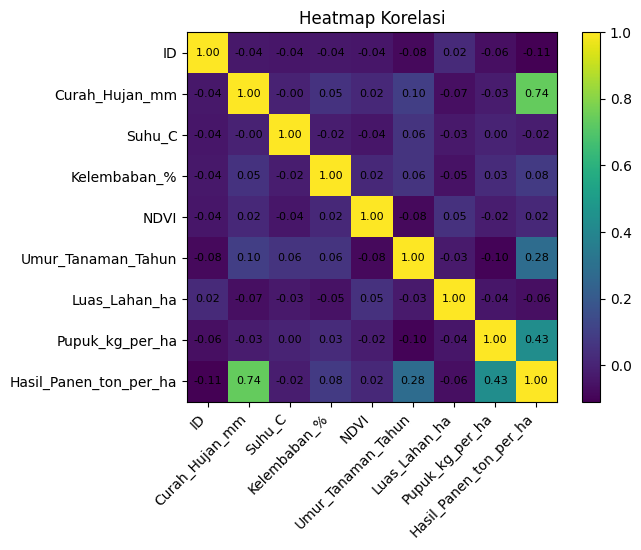

In [38]:
corr = data.select_dtypes(include='number').corr()

fig, ax = plt.subplots()

im = ax.imshow(corr.values)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha='center', va='center', fontsize=8)

plt.colorbar(im)
ax.set_title("Heatmap Korelasi")
plt.show()

## 4. SCATTER PLOT

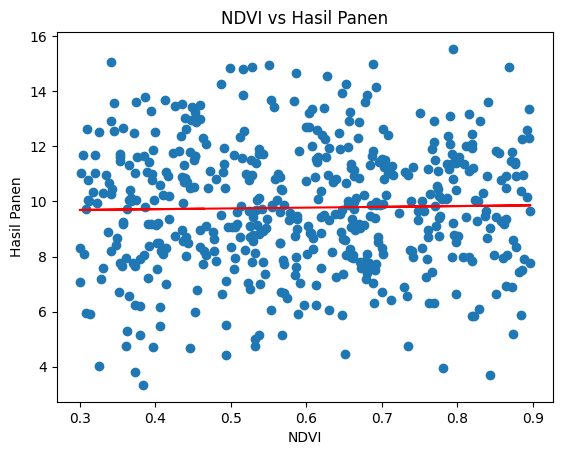

In [39]:
x = data['NDVI']
y = data['Hasil_Panen_ton_per_ha']

fig, ax = plt.subplots()

ax.scatter(x, y)

if len(x) > 1:
    m, b = np.polyfit(x, y, 1)
    ax.plot(x, m*x + b, color='red')

ax.set_title("NDVI vs Hasil Panen")
ax.set_xlabel("NDVI")
ax.set_ylabel("Hasil Panen")

plt.show()

## 5. HISTOGRAM

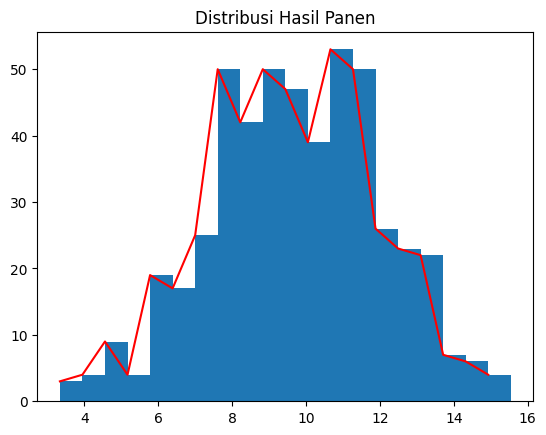

In [40]:
fig, ax = plt.subplots()

n, bins, patches = ax.hist(data['Hasil_Panen_ton_per_ha'], bins=20)
ax.plot(bins[:-1], n, color='red')

ax.set_title("Distribusi Hasil Panen")

plt.show()

## 6. PREDIKSI TINGGI/RENDAH

In [41]:
rata = data['Hasil_Panen_ton_per_ha'].mean()

print("Rata-rata hasil panen:", rata)

curah = 100
pupuk = 50
lahan = 2

skor = (curah + pupuk + lahan * 100) / 3

print("Skor prediksi:", skor)

if skor >= rata:
    print("Hasil Panen: TINGGI")
else:
    print("Hasil Panen: RENDAH")

Rata-rata hasil panen: 9.77522
Skor prediksi: 116.66666666666667
Hasil Panen: TINGGI


## 7. VISUALISASI HASIL PREDIKSI

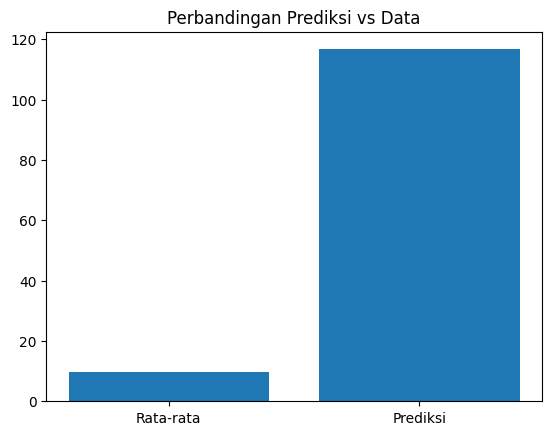

In [42]:
fig, ax = plt.subplots()

ax.bar(['Rata-rata', 'Prediksi'], [rata, skor])
ax.set_title("Perbandingan Prediksi vs Data")

plt.show()